In [1]:
import pandas as pd
import re

# 서울시 대로변 횡단보도 위치정보

## 1. 데이터 불러오기 및 확인

In [15]:
df_raw = pd.read_csv(
    "/Users/danha/Desktop/IT/project/team_project_brew_map/data/raw/서울시 대로변 횡단보도 위치정보.csv",
    encoding="cp949"
)

print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
df_raw.head()

Shape: (31080, 14)
Columns: ['노드링크 유형', '노드 WKT', '노드 ID', '노드 유형 코드', '링크 WKT', '링크 ID', '링크 유형 코드', '시작노드 ID', '종료노드 ID', '링크 길이', '시군구코드', '시군구명', '읍면동코드', '읍면동명']


,노드링크 유형,노드 WKT,노드 ID,노드 유형 코드,링크 WKT,링크 ID,링크 유형 코드,시작노드 ID,종료노드 ID,링크 길이,시군구코드,시군구명,읍면동코드,읍면동명
0,NODE,POINT(127.00215341892462 37.57353369522703),137973,0.0,NaN,0,NaN,NaN,NaN,NaN,1111000000,종로구,1111016000,연지동
1,NODE,POINT(127.00223985835923 37.573476755009715),137972,0.0,NaN,0,NaN,NaN,NaN,NaN,1111000000,종로구,1111016000,연지동
2,NODE,POINT(127.00213875687398 37.58198076927101),137301,0.0,NaN,0,NaN,NaN,NaN,NaN,1111000000,종로구,1111016800,동숭동
3,NODE,POINT(127.00223388953587 37.573230021144475),137971,0.0,NaN,0,NaN,NaN,NaN,NaN,1111000000,종로구,1111016200,효제동
4,NODE,POINT(127.00213254211845 37.57312326312107),137970,0.0,NaN,0,NaN,NaN,NaN,NaN,1111000000,종로구,1111016200,효제동


In [16]:
print('=== 데이터 타입 ===')
print(df_raw.dtypes)
print()
print('=== 결측값 현황 ===')
print(df_raw.isnull().sum())
print()
print('=== 노드링크 유형 분포 ===')
print(df_raw['노드링크 유형'].value_counts())

=== 데이터 타입 ===
노드링크 유형      object
노드 WKT       object
노드 ID         int64
노드 유형 코드    float64
링크 WKT       object
링크 ID         int64
링크 유형 코드    float64
시작노드 ID     float64
종료노드 ID     float64
링크 길이       float64
시군구코드         int64
시군구명         object
읍면동코드         int64
읍면동명         object
dtype: object

=== 결측값 현황 ===
노드링크 유형         0
노드 WKT      11562
노드 ID           0
노드 유형 코드    11562
링크 WKT      19518
링크 ID           0
링크 유형 코드    19518
시작노드 ID     19518
종료노드 ID     19518
링크 길이       19518
시군구코드           0
시군구명            0
읍면동코드           0
읍면동명            0
dtype: int64

=== 노드링크 유형 분포 ===
노드링크 유형
NODE    19518
LINK    11562
Name: count, dtype: int64


## 2. 핵심 데이터 추출

- `NODE` : 횡단보도 위치 좌표
- `LINK` : 노드 간 연결 경로 정보

In [4]:
# NODE 행만 추출 (횡단보도 위치 좌표)
df = df_raw[df_raw['노드링크 유형'] == 'NODE'].copy()

# NODE에서 의미 있는 컬럼만 선택
node_cols = ['노드링크 유형', '노드 WKT', '노드 ID', '노드 유형 코드',
             '시군구코드', '시군구명', '읍면동코드', '읍면동명']
df = df[node_cols]

print(f'추출 후 Shape: {df.shape}')
df.head()

추출 후 Shape: (19518, 8)


,노드링크 유형,노드 WKT,노드 ID,노드 유형 코드,시군구코드,시군구명,읍면동코드,읍면동명
0,NODE,POINT(127.00215341892462 37.57353369522703),137973,0.0,1111000000,종로구,1111016000,연지동
1,NODE,POINT(127.00223985835923 37.573476755009715),137972,0.0,1111000000,종로구,1111016000,연지동
2,NODE,POINT(127.00213875687398 37.58198076927101),137301,0.0,1111000000,종로구,1111016800,동숭동
3,NODE,POINT(127.00223388953587 37.573230021144475),137971,0.0,1111000000,종로구,1111016200,효제동
4,NODE,POINT(127.00213254211845 37.57312326312107),137970,0.0,1111000000,종로구,1111016200,효제동


## 3. 열 이름 영소문자로 변경

In [5]:
col_rename = {
    '노드링크 유형' : 'type',
    '노드 WKT'    : 'wkt',
    '노드 ID'     : 'node_id',
    '노드 유형 코드': 'node_type_code',
    '시군구코드'    : 'sigungu_code',
    '시군구명'     : 'sigungu_name',
    '읍면동코드'   : 'emd_code',
    '읍면동명'     : 'emd_name'
}

df = df.rename(columns=col_rename)
print('변환된 컬럼명:', df.columns.tolist())
df.head()

변환된 컬럼명: ['type', 'wkt', 'node_id', 'node_type_code', 'sigungu_code', 'sigungu_name', 'emd_code', 'emd_name']


,type,wkt,node_id,node_type_code,sigungu_code,sigungu_name,emd_code,emd_name
0,NODE,POINT(127.00215341892462 37.57353369522703),137973,0.0,1111000000,종로구,1111016000,연지동
1,NODE,POINT(127.00223985835923 37.573476755009715),137972,0.0,1111000000,종로구,1111016000,연지동
2,NODE,POINT(127.00213875687398 37.58198076927101),137301,0.0,1111000000,종로구,1111016800,동숭동
3,NODE,POINT(127.00223388953587 37.573230021144475),137971,0.0,1111000000,종로구,1111016200,효제동
4,NODE,POINT(127.00213254211845 37.57312326312107),137970,0.0,1111000000,종로구,1111016200,효제동


## 4. 중복값 확인

In [17]:
print(f'처리 전 행 수: {len(df)}')
print(f'전체 중복 행 수: {df.duplicated().sum()}')
print(f'node_id 기준 중복 수: {df.duplicated(subset=["node_id"]).sum()}')


df = df.drop_duplicates(subset=['node_id'])
print(f'중복 제거 후 행 수: {len(df)}')

처리 전 행 수: 19518
전체 중복 행 수: 0
node_id 기준 중복 수: 0
중복 제거 후 행 수: 19518


## 5. WKT 컬럼에서 경도 / 위도 분리

`POINT(127.002153... 37.573533...)` → `longitude` / `latitude` 분리

In [7]:
def parse_wkt(wkt_str):
    
    match = re.search(r'POINT\(([\d.]+)\s+([\d.]+)\)', str(wkt_str))
    if match:
        return float(match.group(1)), float(match.group(2))
    return None, None

df[['lon', 'lat']] = df['wkt'].apply(
    lambda x: pd.Series(parse_wkt(x))
)

print('파싱 실패 건수:', df['lon'].isnull().sum())
print()
print(df[['wkt', 'lon', 'lat']].head())

파싱 실패 건수: 0

                                            wkt         lon        lat
0   POINT(127.00215341892462 37.57353369522703)  127.002153  37.573534
1  POINT(127.00223985835923 37.573476755009715)  127.002240  37.573477
2   POINT(127.00213875687398 37.58198076927101)  127.002139  37.581981
3  POINT(127.00223388953587 37.573230021144475)  127.002234  37.573230
4   POINT(127.00213254211845 37.57312326312107)  127.002133  37.573123


## 6. 이상치 제거

### 6.1 이상치 확인

In [8]:
LON_MIN, LON_MAX = 126.76, 127.18
LAT_MIN, LAT_MAX = 37.43, 37.70

is_outlier = (
    ~df['lon'].between(LON_MIN, LON_MAX) |
    ~df['lat'].between(LAT_MIN, LAT_MAX)
)

outliers = df[is_outlier]
print(f'이상치 {len(outliers)}건')
print()
outliers[['node_id', 'lon', 'lat', 'sigungu_name', 'emd_name']]

이상치 19건



,node_id,lon,lat,sigungu_name,emd_name
29908,86569,127.180152,37.561552,강동구,강일동
29909,86570,127.180197,37.561510,강동구,강일동
29910,86571,127.180269,37.561481,강동구,강일동
29913,86572,127.180283,37.561307,강동구,강일동
29915,86574,127.180228,37.561282,강동구,강일동
29916,86756,127.181669,37.561499,강동구,강일동
29917,86761,127.181549,37.561865,강동구,강일동
30132,201292,127.181528,37.561463,강동구,강일동
30424,201182,127.180018,37.558319,강동구,강일동
30435,201166,127.181652,37.558906,강동구,강일동


### 6.2 이상치인 이유 찾기

In [9]:
print('경도 초과 (동쪽):', len(df[df['lon'] > LON_MAX]))
print('경도 미달 (서쪽):', len(df[df['lon'] < LON_MIN]))
print('위도 초과 (북쪽):', len(df[df['lat'] > LAT_MAX]))
print('위도 미달 (남쪽):', len(df[df['lat'] < LAT_MIN]))

경도 초과 (동쪽): 19
경도 미달 (서쪽): 0
위도 초과 (북쪽): 0
위도 미달 (남쪽): 0


/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_42411/3818606704.py:36: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_42411/3818606704.py:36: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_42411/3818606704.py:36: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_42411/3818606704.py:36: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_42411/3818606704.py:36: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipyke

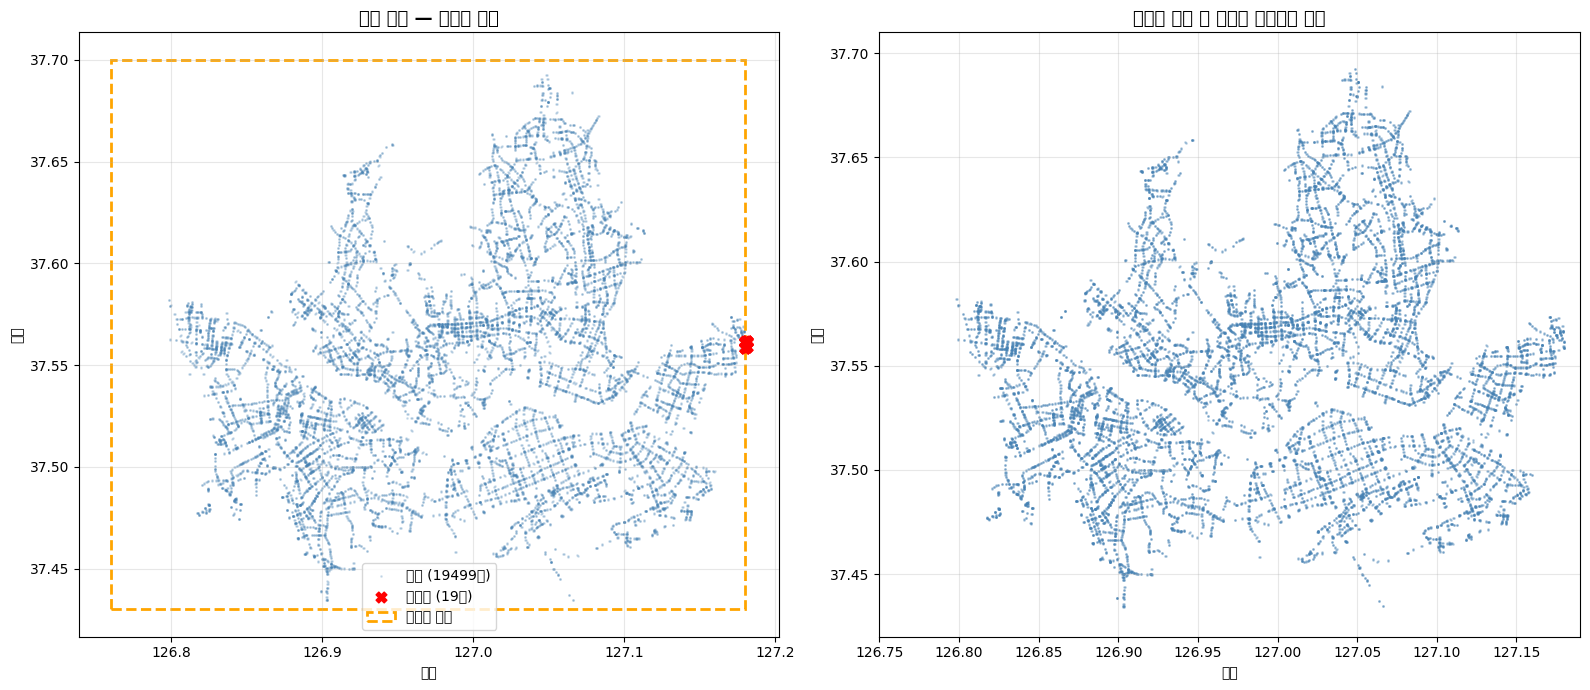

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

normal   = df[~is_outlier]
outliers = df[is_outlier]

# 왼쪽: 전체 뷰 (이상치가 어디 찍혔는지)
ax1 = axes[0]
ax1.scatter(normal['lon'], normal['lat'],
            s=1, alpha=0.2, color='steelblue', label=f'정상 ({len(normal)}건)')
ax1.scatter(outliers['lon'], outliers['lat'],
            s=60, alpha=1.0, color='red', marker='X', zorder=5,
            label=f'이상치 ({len(outliers)}건)')
rect = mpatches.FancyBboxPatch(
    (LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
    boxstyle='square,pad=0', linewidth=2,
    edgecolor='orange', facecolor='none', linestyle='--', label='서울시 경계'
)
ax1.add_patch(rect)
ax1.set_title('전체 분포 — 이상치 위치', fontsize=13, fontweight='bold')
ax1.set_xlabel('경도'); ax1.set_ylabel('위도')
ax1.legend(); ax1.grid(alpha=0.3)

# 오른쪽: 서울 범위만 확대 (이상치 제거 후)
ax2 = axes[1]
ax2.scatter(normal['lon'], normal['lat'],
            s=1, alpha=0.3, color='steelblue')
ax2.set_xlim(LON_MIN - 0.01, LON_MAX + 0.01)
ax2.set_ylim(LAT_MIN - 0.01, LAT_MAX + 0.01)
ax2.set_title('이상치 제거 후 서울시 횡단보도 분포', fontsize=13, fontweight='bold')
ax2.set_xlabel('경도'); ax2.set_ylabel('위도')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### -> 실제 서울 동쪽 끝은 약 127.20 ~ 127.22 라서 경계값을 완화시켰다.

In [11]:
LON_MIN, LON_MAX = 126.76, 127.22
LAT_MIN, LAT_MAX = 37.43, 37.72

is_outlier = (
    ~df['lon'].between(LON_MIN, LON_MAX) |
    ~df['lat'].between(LAT_MIN, LAT_MAX)
)

outliers = df[is_outlier]
print(f'이상치 {len(outliers)}건')
print()
outliers[['node_id', 'lon', 'lat', 'sigungu_name', 'emd_name']]

이상치 0건



,node_id,lon,lat,sigungu_name,emd_name


## 7. 불필요한 컬럼 정리 및 최종 데이터 확인

In [12]:
# wkt 원본 컬럼 제거 (longitude/latitude로 대체됨)
# type 컬럼 제거 (전부 NODE로 동일)
df = df.drop(columns=['wkt', 'type'])

# 컬럼 순서 정리
df = df[['node_id', 'node_type_code', 'lon', 'lat',
          'sigungu_code', 'sigungu_name', 'emd_code', 'emd_name']]

# 인덱스 리셋
df = df.reset_index(drop=True)

print('=== 최종 데이터프레임 ===')
print(f'Shape: {df.shape}')
print()
print(df.dtypes)
print()
df.head(10)

=== 최종 데이터프레임 ===
Shape: (19518, 8)

node_id             int64
node_type_code    float64
lon               float64
lat               float64
sigungu_code        int64
sigungu_name       object
emd_code            int64
emd_name           object
dtype: object



,node_id,node_type_code,lon,lat,sigungu_code,sigungu_name,emd_code,emd_name
0,137973,0.0,127.002153,37.573534,1111000000,종로구,1111016000,연지동
1,137972,0.0,127.002240,37.573477,1111000000,종로구,1111016000,연지동
2,137301,0.0,127.002139,37.581981,1111000000,종로구,1111016800,동숭동
3,137971,0.0,127.002234,37.573230,1111000000,종로구,1111016200,효제동
4,137970,0.0,127.002133,37.573123,1111000000,종로구,1111016200,효제동
5,137969,0.0,127.001909,37.573123,1111000000,종로구,1111016000,연지동
6,137967,0.0,127.001861,37.573185,1111000000,종로구,1111016000,연지동
7,137966,0.0,127.001852,37.573408,1111000000,종로구,1111016000,연지동
8,193200,0.0,127.006502,37.571002,1111000000,종로구,1111016400,종로6가
9,193217,0.0,126.977376,37.575438,1111000000,종로구,1111011900,세종로


In [13]:
# 전처리 완료 데이터 저장

save_path = "/Users/danha/Desktop/IT/project/team_project_brew_map/data/dh/crosswalk_clean.csv"

df.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료:", save_path)

저장 완료: /Users/danha/Desktop/IT/project/team_project_brew_map/data/dh/crosswalk_clean.csv


## 8. 매물 기준 300m 내 횡단보도 여부 확인 함수

In [14]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    """두 좌표 간 거리 반환 (단위: 미터)"""
    R = 6371000
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

def crosswalk_nearby(property_lat, property_lon, crosswalk_df, radius_m=300):
    """
    매물 좌표 기준 반경 내 횡단보도 검색
    Returns:
        has_crosswalk (bool): 횡단보도 존재 여부
        count (int)         : 반경 내 횡단보도 개수
        nearby_df           : 반경 내 횡단보도 데이터프레임 (거리 포함)
    """
    dist = crosswalk_df.apply(
        lambda row: haversine(property_lat, property_lon,
                              row['latitude'], row['longitude']), axis=1
    )
    nearby_df = crosswalk_df[dist <= radius_m].copy()
    nearby_df['distance_m'] = dist[dist <= radius_m].round(1)
    nearby_df = nearby_df.sort_values('distance_m').reset_index(drop=True)
    return len(nearby_df) > 0, len(nearby_df), nearby_df


# ── 사용 예시 ──────────────────────────────────────────────────
# property_lat, property_lon = 37.5665, 126.9780  # 매물 좌표
# has_cw, count, nearby = crosswalk_nearby(property_lat, property_lon, df)
# print(f'300m 내 횡단보도: {has_cw}  /  개수: {count}건')
# nearby